# Proyecto Implementacion fase 1
- Javier Prado 21486
- Bryan España 21550

## Dataset a utilizar
El dataset a utilizar es sacado de:
https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset
Este es el conjunto de datos de evaluación de detección de intrusiones (CIC-IDS2017). 

## Construcción del dataset (CIC-IDS2017)

El dataset CIC-IDS2017 fue construido por el Canadian Institute for Cybersecurity (CIC) con el objetivo de crear un conjunto de datos realista y actualizado para la evaluación de sistemas de detección de intrusiones (IDS). A diferencia de datasets antiguos, este fue diseñado para simular el comportamiento real de una red empresarial bajo condiciones normales y bajo ataque.

## Cómo fue construido

El dataset se generó en un entorno controlado de red durante un período de aproximadamente 5 días (lunes a viernes), donde se simuló el tráfico de una organización real. Durante este proceso:

Se configuró una infraestructura con múltiples máquinas (atacantes y víctimas) que representaban una red empresarial real.
Se generó tráfico normal (benigno) utilizando perfiles de comportamiento de usuarios reales, simulando actividades como navegación web, envío de correos, uso de FTP y SSH.
A partir del segundo día, se ejecutaron distintos tipos de ataques controlados en la red, incluyendo:
Ataques de fuerza bruta (FTP y SSH)
Ataques DoS y DDoS
Escaneo de puertos
Ataques web (SQL Injection, XSS)
Botnets e infiltraciones
Heartbleed

Todo el tráfico de red fue capturado en formato PCAP (packet capture), lo que representa los paquetes reales transmitidos en la red.

## Procesamiento de los datos

Posteriormente, los datos capturados fueron procesados utilizando una herramienta llamada CICFlowMeter, que transforma el tráfico de red en flujos (flows).

Un flow representa una comunicación entre dos dispositivos (IP origen y destino), y de cada flujo se extraen múltiples características como:

Número de paquetes
Duración del flujo
Tamaño de paquetes
Flags TCP
Estadísticas (media, desviación estándar, etc.)

Esto permitió generar alrededor de 80 características por flujo.

Características del conjunto de datos

![Descripción](imagen.png)

## Labels

Cada flujo fue etiquetado como:

Benigno (normal)
Ataque (con tipo específico)

En total, el dataset contiene múltiples clases de ataque además de la clase normal, lo que lo hace ideal para problemas de clasificación supervisada en Machine Learning.

# Analisis exploratorio

In [1]:
# Para descargar el dataset se debe descargar con el siguiente codigo
# se mantendra comentada esta seccion para evitar descargar el dataset cada vez que se ejecute el codigo

# al ejecutarlo se creara una carpeta en la carpeta del repo, dentro de esta carpeta se descargara el dataset
from pathlib import Path
import kagglehub
import shutil

# 📁 Ruta base (donde está el notebook)
BASE_DIR = Path().resolve()

# 📁 Carpeta dataset dentro del proyecto
DATASET_DIR = BASE_DIR / "dataset"
DATASET_HANDLE = "chethuhn/network-intrusion-dataset"

# Crear carpeta si no existe
DATASET_DIR.mkdir(parents=True, exist_ok=True)

# Evitar descargar si ya existe contenido
if any(DATASET_DIR.iterdir()):
    print("⚡ Dataset ya existe en:", DATASET_DIR)
else:
    print("📥 Descargando dataset...")

    # Descargar dataset con el identificador completo de Kaggle
    download_path = Path(kagglehub.dataset_download(DATASET_HANDLE))

    # Copiar archivos desde la caché de Kaggle al proyecto
    for source in download_path.iterdir():
        destination = DATASET_DIR / source.name
        if source.is_dir():
            shutil.copytree(source, destination, dirs_exist_ok=True)
        else:
            shutil.copy2(source, destination)

    print("✅ Dataset descargado en:", DATASET_DIR)

/Users/bryanespana/Documents/UVG/SecurityDataScience/proyecto/Intrusion_Detection_System/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📥 Descargando dataset...


100%|██████████| 230M/230M [00:12<00:00, 18.6MB/s] 

Extracting files...


✅ Dataset descargado en: /Users/bryanespana/Documents/UVG/SecurityDataScience/proyecto/Intrusion_Detection_System/dataset


## Analisis exploratorio detallado

Este bloque construye un EDA orientado a describir el dataset **CIC-IDS2017** desde cuatro angulos:

- estructura general del conjunto de datos
- distribucion de clases y archivos
- calidad de datos y variables redundantes
- caracteristicas clave mas informativas para distinguir trafico benigno y ataques


Construyendo vista general del dataset...
Evaluando calidad de datos...
Generando muestra balanceada para visualizacion y ranking de variables...


## 1. Vista general del dataset

,metric,value
0,Archivos CSV,8
1,Registros totales,2830743
2,Caracteristicas numericas y de red,78
3,Clases de trafico,15


,file,rows,classes,benign_pct,attack_pct,dominant_attack,dominant_attack_rows
0,Wednesday-workingHours.pcap_ISCX.csv,692703,6,63.52,36.48,DoS Hulk,231073
1,Monday-WorkingHours.pcap_ISCX.csv,529918,1,100.00,0.00,None,0
2,Tuesday-WorkingHours.pcap_ISCX.csv,445909,3,96.90,3.10,FTP-Patator,7938
3,Thursday-WorkingHours-Afternoon-Infilteration....,288602,2,99.99,0.01,Infiltration,36
4,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,286467,2,44.52,55.48,PortScan,158930
5,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,225745,2,43.29,56.71,DDoS,128027
6,Friday-WorkingHours-Morning.pcap_ISCX.csv,191033,2,98.97,1.03,Bot,1966
7,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,170366,4,98.72,1.28,Web Attack - Brute Force,1507


,label,count,pct
0,BENIGN,2273097,80.3004
1,DoS Hulk,231073,8.1630
2,PortScan,158930,5.6144
3,DDoS,128027,4.5227
4,DoS GoldenEye,10293,0.3636
5,FTP-Patator,7938,0.2804
6,SSH-Patator,5897,0.2083
7,DoS slowloris,5796,0.2048
8,DoS Slowhttptest,5499,0.1943
9,Bot,1966,0.0695


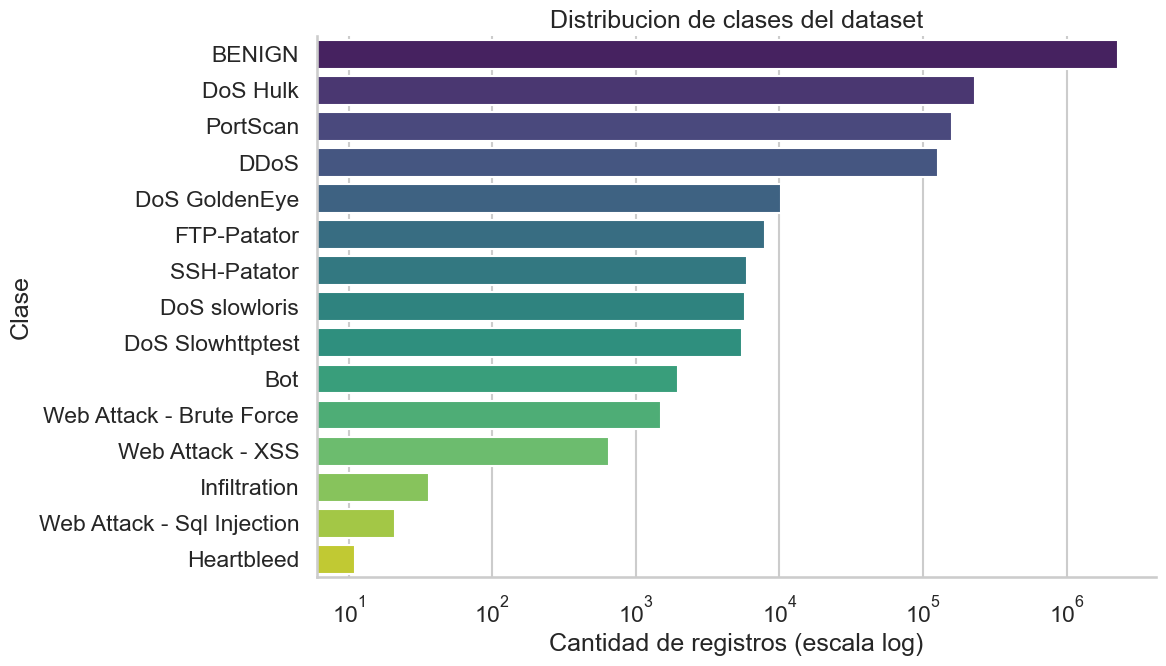

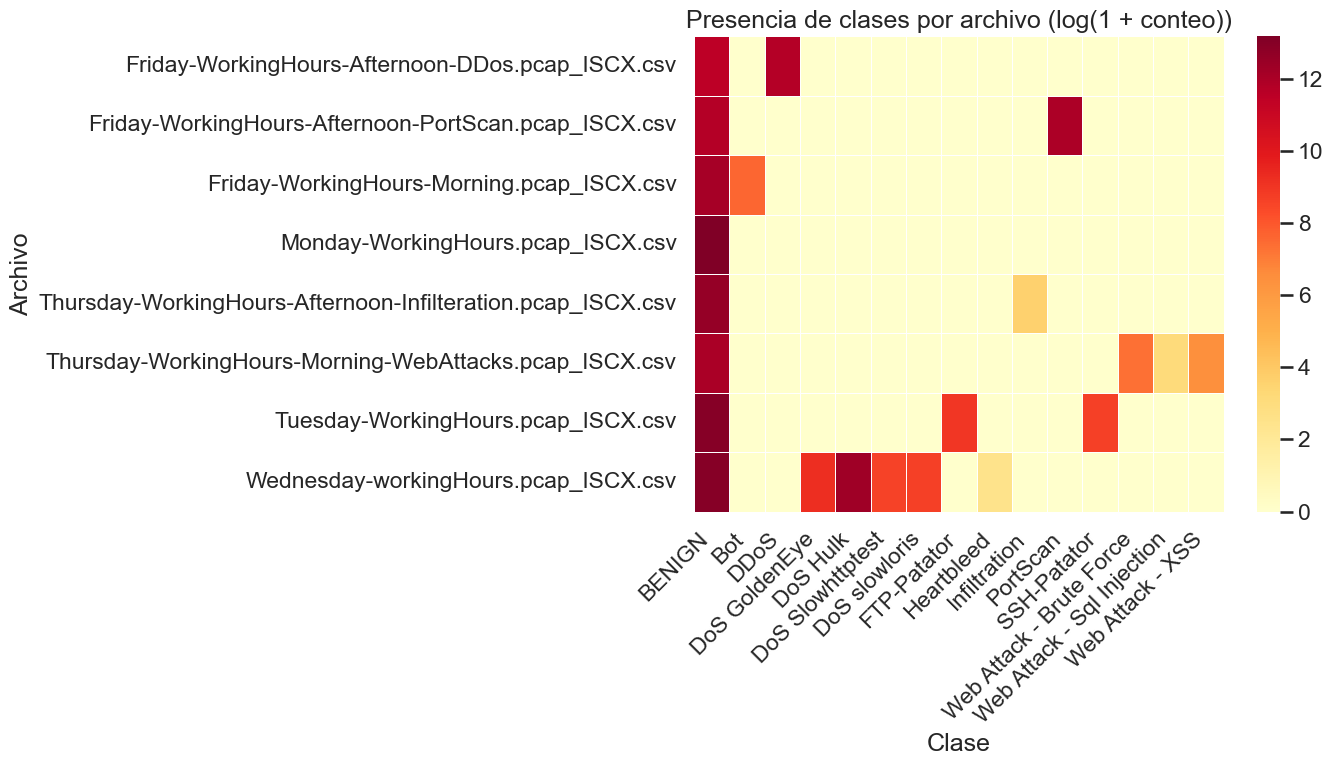

## 2. Calidad de datos y variables redundantes

,feature,missing_values,infinite_values
0,Flow Packets/s,0,2867
1,Flow Bytes/s,1358,1509


,file,duplicate_rows,duplicate_pct
0,Wednesday-workingHours.pcap_ISCX.csv,81909,11.82
1,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,72353,25.26
2,Thursday-WorkingHours-Afternoon-Infilteration....,35630,12.35
3,Monday-WorkingHours.pcap_ISCX.csv,26935,5.08
4,Tuesday-WorkingHours.pcap_ISCX.csv,24065,5.40
5,Friday-WorkingHours-Morning.pcap_ISCX.csv,6888,3.61
6,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,6066,3.56
7,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,2633,1.17


,constant_feature
0,Bwd PSH Flags
1,Bwd URG Flags
2,Fwd Avg Bytes/Bulk
3,Fwd Avg Packets/Bulk
4,Fwd Avg Bulk Rate
5,Bwd Avg Bytes/Bulk
6,Bwd Avg Packets/Bulk
7,Bwd Avg Bulk Rate


,feature_a,feature_b
0,Total Fwd Packets,Subflow Fwd Packets
1,Total Backward Packets,Subflow Bwd Packets
2,Fwd Header Length,Fwd Header Length.1


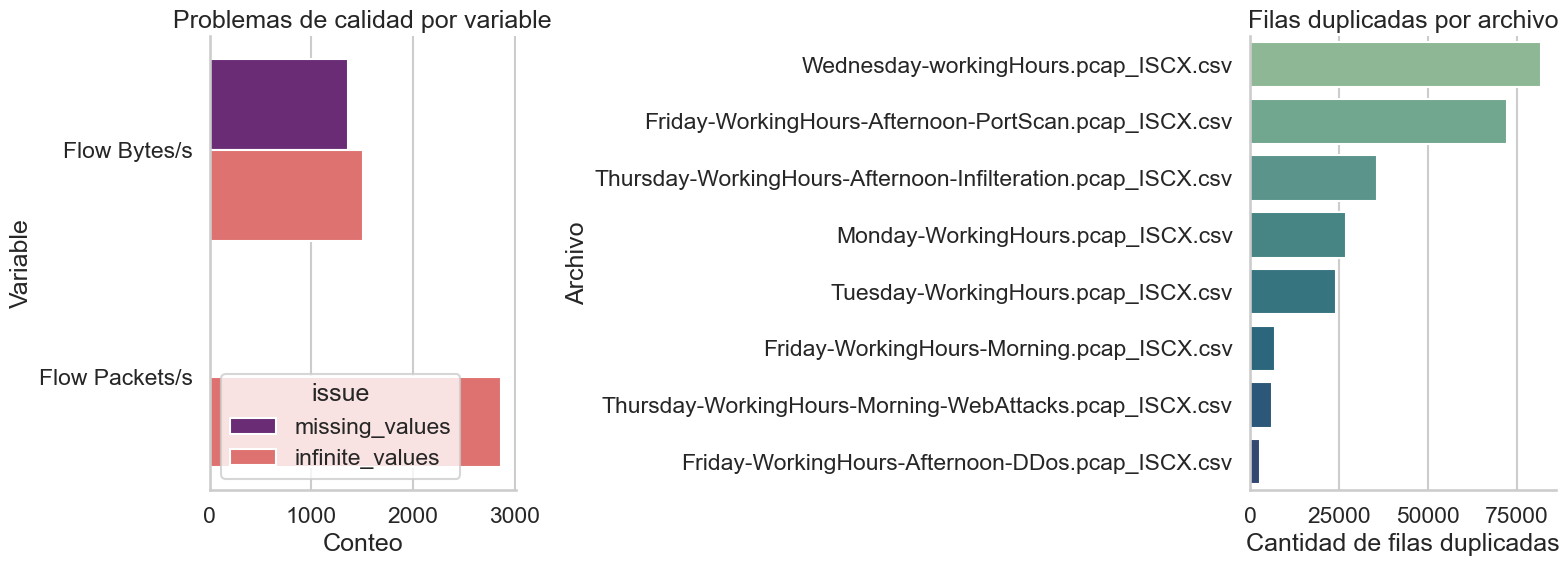

## 3. Caracteristicas clave del trafico

,feature,category,description,security_value,mutual_info,attack_vs_benign_shift
0,Fwd Header Length,Cabeceras y control,Longitud acumulada de cabeceras en direccion f...,Suele correlacionar con la cantidad y tipo de ...,1.7102,0.0185
1,Average Packet Size,Tamano de paquetes,Promedio general de bytes por paquete del flujo.,Resume el perfil de tamano de la sesion y suel...,1.6943,0.1550
2,Packet Length Mean,Tamano de paquetes,Tamano promedio de los paquetes observados en ...,Los ataques automatizados suelen mostrar perfi...,1.6939,0.1379
3,Flow IAT Max,Temporalidad,Mayor tiempo entre llegadas dentro del flujo.,Ayuda a encontrar flujos con pausas largas o c...,1.6559,0.0822
4,Flow Duration,Temporalidad,Duracion total del flujo desde el primer hasta...,"Separa ataques muy breves y repetitivos, como ...",1.6454,0.1449
5,Flow IAT Mean,Temporalidad,Promedio del tiempo entre llegadas sucesivas d...,Distingue patrones regulares de automatizacion...,1.6323,0.0369
6,Flow Packets/s,Volumen,Tasa de paquetes por segundo del flujo.,"Es especialmente util para evidenciar DDoS, Do...",1.6316,0.0005
7,Fwd IAT Max,Temporalidad,Maximo tiempo entre llegadas en direccion forw...,"Resalta pausas largas del emisor, utiles para ...",1.6136,0.0802
8,Fwd Packets/s,Volumen,Paquetes por segundo emitidos en direccion for...,Es util para reconocer rafagas del cliente dur...,1.6119,0.0003
9,Fwd IAT Mean,Temporalidad,Promedio del tiempo entre llegadas en direccio...,Permite comparar la cadencia con la que el ori...,1.5873,0.0389


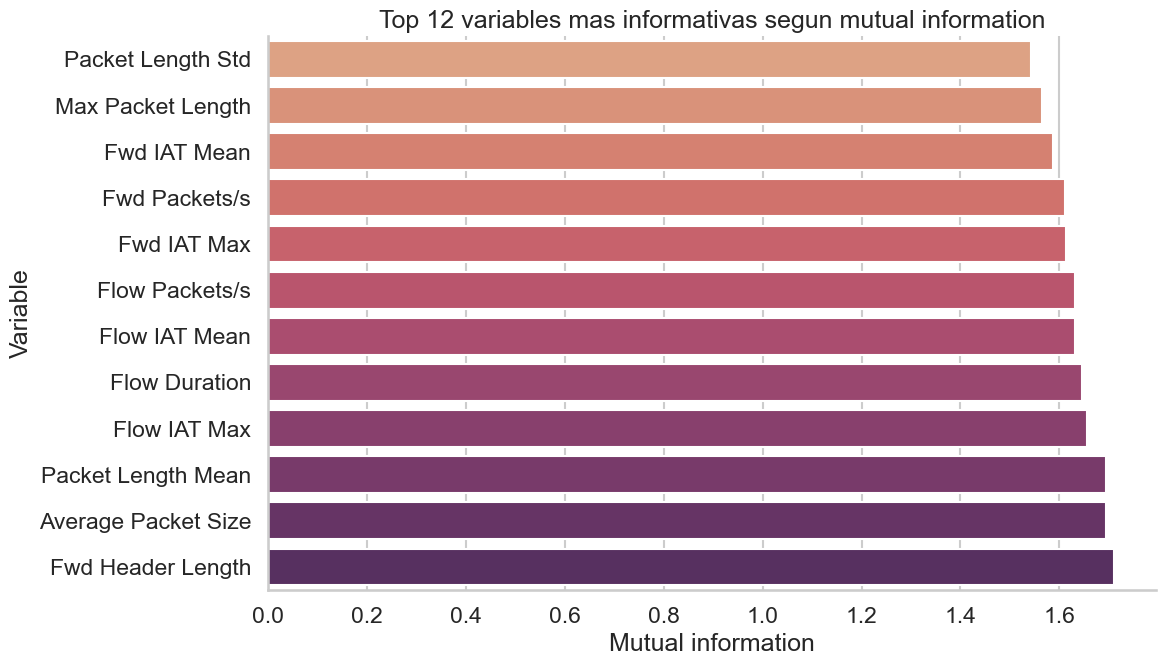

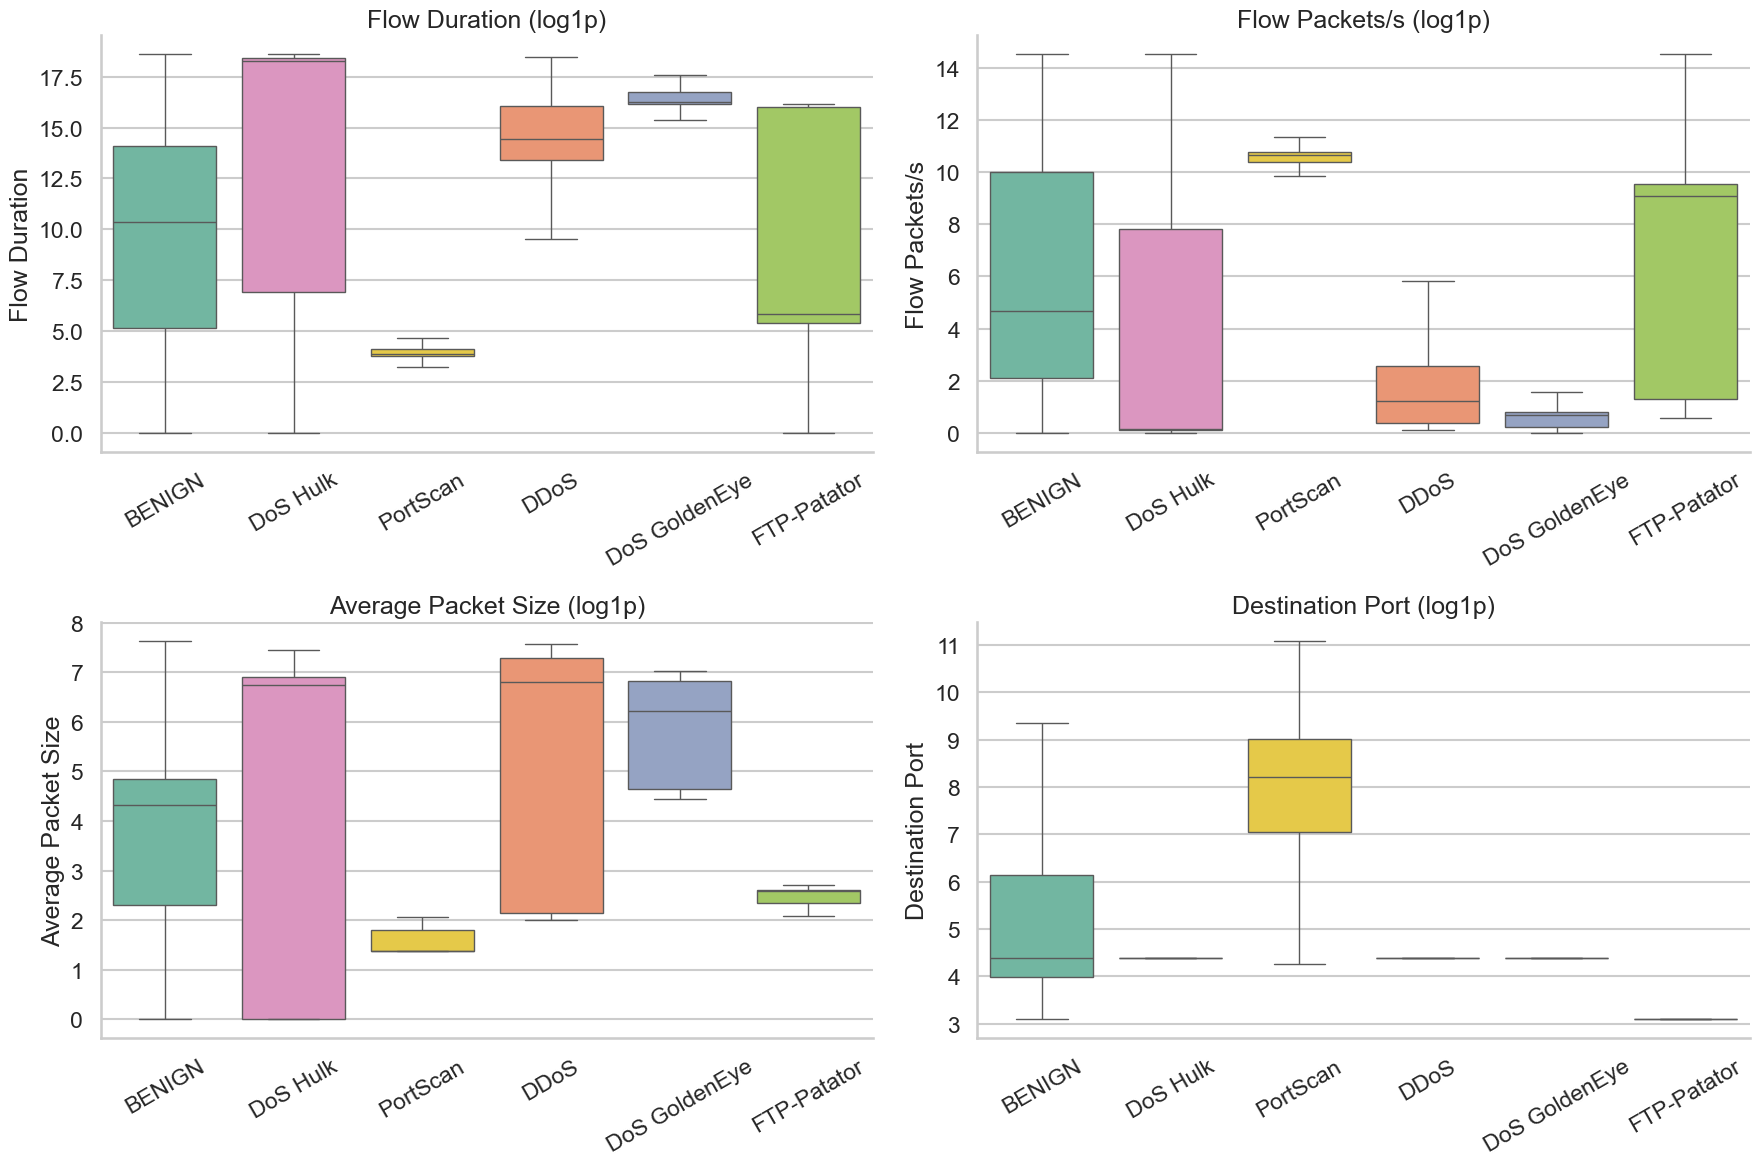

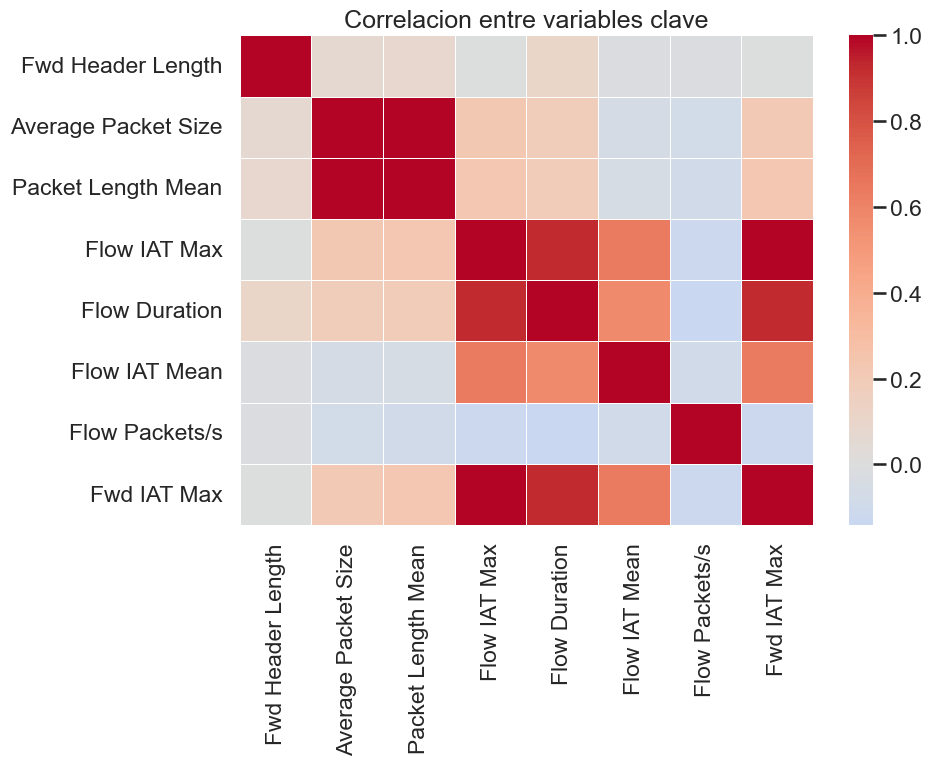

### Hallazgos principales
- El conjunto contiene **2,830,743 registros**, **78 variables** y **15 clases** distribuidas en **8 archivos** diarios.
- Existe un **desbalance fuerte de clases**: las mas frecuentes son BENIGN (80.30%), DoS Hulk (8.16%), PortScan (5.61%), DDoS (4.52%). Esto implica que metricas de accuracy por si solas serian enganiosas en etapas de modelado.
- La estructura temporal del dataset es muy util para el contexto: **Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv** es el archivo con mayor proporcion de ataques (56.71%), mientras que **Wednesday-workingHours.pcap_ISCX.csv** concentra la mayor diversidad de clases (6 clases).
- Los principales problemas de calidad estan concentrados en **Flow Packets/s, Flow Bytes/s**, con infinitos generados por divisiones sobre tasas, ademas de **256,479 filas duplicadas** dentro de archivos.
- Se detectaron **8 columnas constantes** y **3 pares de columnas redundantes exactas**, por lo que conviene excluirlas antes de entrenar modelos.
- Las variables con mas señal combinan **Cabeceras y control, Tamano de paquetes, Temporalidad, Volumen**. En especial destacan medidas de duracion, tasas por segundo, tamanos de paquete y longitud de cabeceras en direccion forward.
- Para la narrativa del informe, una buena idea es explicar las variables clave por familias: **volumen**, **temporalidad**, **tamano de paquetes**, **simetria del flujo** y **banderas TCP**.

In [2]:
from cicids_eda import run_eda

artifacts = run_eda(DATASET_DIR)


In [3]:
# Tabla de caracteristicas clave para el reporte
feature_report = (
    artifacts["key_features"][["feature", "category", "description", "security_value", "mutual_info", "attack_vs_benign_shift"]]
    .rename(columns={
        "feature": "Caracteristica",
        "category": "Categoria",
        "description": "Descripcion",
        "security_value": "Valor para IDS",
        "mutual_info": "Mutual information",
        "attack_vs_benign_shift": "Cambio ataque vs benigno",
    })
)

feature_report


,Caracteristica,Categoria,Descripcion,Valor para IDS,Mutual information,Cambio ataque vs benigno
0,Fwd Header Length,Cabeceras y control,Longitud acumulada de cabeceras en direccion f...,Suele correlacionar con la cantidad y tipo de ...,1.7102,0.0185
1,Average Packet Size,Tamano de paquetes,Promedio general de bytes por paquete del flujo.,Resume el perfil de tamano de la sesion y suel...,1.6943,0.1550
2,Packet Length Mean,Tamano de paquetes,Tamano promedio de los paquetes observados en ...,Los ataques automatizados suelen mostrar perfi...,1.6939,0.1379
3,Flow IAT Max,Temporalidad,Mayor tiempo entre llegadas dentro del flujo.,Ayuda a encontrar flujos con pausas largas o c...,1.6559,0.0822
4,Flow Duration,Temporalidad,Duracion total del flujo desde el primer hasta...,"Separa ataques muy breves y repetitivos, como ...",1.6454,0.1449
5,Flow IAT Mean,Temporalidad,Promedio del tiempo entre llegadas sucesivas d...,Distingue patrones regulares de automatizacion...,1.6323,0.0369
6,Flow Packets/s,Volumen,Tasa de paquetes por segundo del flujo.,"Es especialmente util para evidenciar DDoS, Do...",1.6316,0.0005
7,Fwd IAT Max,Temporalidad,Maximo tiempo entre llegadas en direccion forw...,"Resalta pausas largas del emisor, utiles para ...",1.6136,0.0802
8,Fwd Packets/s,Volumen,Paquetes por segundo emitidos en direccion for...,Es util para reconocer rafagas del cliente dur...,1.6119,0.0003
9,Fwd IAT Mean,Temporalidad,Promedio del tiempo entre llegadas en direccio...,Permite comparar la cadencia con la que el ori...,1.5873,0.0389


In [4]:
from IPython.display import Markdown, display

overview = artifacts["overview"].set_index("metric")["value"]
label_distribution = artifacts["label_distribution"].copy()
quality = artifacts["quality"].copy()
duplicates = artifacts["duplicates"].copy()

top_attacks = label_distribution[label_distribution["label"] != "BENIGN"].head(3)
top_attacks_text = ", ".join(
    f"{row.label} ({row.pct:.2f}%)"
    for row in top_attacks.itertuples(index=False)
)

rare_classes = label_distribution[label_distribution["pct"] < 0.01]["label"].tolist()
rare_classes_text = ", ".join(rare_classes) if rare_classes else "ninguna"

quality_notes = []
for row in quality.itertuples(index=False):
    parts = []
    if row.missing_values:
        parts.append(f"{int(row.missing_values)} nulos")
    if row.infinite_values:
        parts.append(f"{int(row.infinite_values)} infinitos")
    quality_notes.append(f"{row.feature}: {'; '.join(parts)}")

duplicate_total = int(duplicates["duplicate_rows"].sum())
quality_notes_text = ", ".join(quality_notes) if quality_notes else "sin problemas de calidad visibles"

display(Markdown(f"""
## Resumen interpretativo del EDA

**Contexto del dataset.** Segun la documentacion oficial del CIC, el trafico fue capturado entre el **3 y el 7 de julio de 2017**. El **lunes** contiene solo trafico benigno y entre **martes y viernes** se introducen ataques de fuerza bruta, DoS/DDoS, web attacks, botnet, infiltration, heartbleed y port scanning.

**Hallazgos principales sobre tu copia del dataset descargada desde Kaggle.**
- El conjunto analizado contiene **{int(overview["Registros totales"]):,} registros**, **{int(overview["Caracteristicas numericas y de red"])} variables** y **{int(overview["Clases de trafico"])} clases**.
- Existe **desbalance de clases**: `BENIGN` representa **{label_distribution.iloc[0]["pct"]:.2f}%** del total. Las familias de ataque mas frecuentes son **{top_attacks_text}**.
- Las clases extremadamente raras son **{rare_classes_text}**, por lo que conviene tratarlas con cuidado al graficar o entrenar modelos.
- Las variables con mas poder descriptivo se concentran en **duracion del flujo**, **tasas por segundo**, **tiempos entre llegadas**, **tamano de paquetes** y **longitud de cabeceras**.
- En calidad de datos se observan **{quality_notes_text}** y **{duplicate_total:,} filas duplicadas** dentro de archivos.
- Antes de modelar, conviene **limpiar infinitos**, **eliminar columnas constantes o redundantes** y usar una estrategia para el **desbalance de clases**.

**Fuentes base para contextualizar el dataset.**
- UNB CIC: https://www.unb.ca/cic/datasets/ids-2017.html
- Kaggle: https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset/data
"""))



## Resumen interpretativo del EDA

**Contexto del dataset.** Segun la documentacion oficial del CIC, el trafico fue capturado entre el **3 y el 7 de julio de 2017**. El **lunes** contiene solo trafico benigno y entre **martes y viernes** se introducen ataques de fuerza bruta, DoS/DDoS, web attacks, botnet, infiltration, heartbleed y port scanning.

**Hallazgos principales sobre tu copia del dataset descargada desde Kaggle.**
- El conjunto analizado contiene **2,830,743 registros**, **78 variables** y **15 clases**.
- Existe **desbalance de clases**: `BENIGN` representa **80.30%** del total. Las familias de ataque mas frecuentes son **DoS Hulk (8.16%), PortScan (5.61%), DDoS (4.52%)**.
- Las clases extremadamente raras son **Infiltration, Web Attack - Sql Injection, Heartbleed**, por lo que conviene tratarlas con cuidado al graficar o entrenar modelos.
- Las variables con mas poder descriptivo se concentran en **duracion del flujo**, **tasas por segundo**, **tiempos entre llegadas**, **tamano de paquetes** y **longitud de cabeceras**.
- En calidad de datos se observan **Flow Packets/s: 2867 infinitos, Flow Bytes/s: 1358 nulos; 1509 infinitos** y **256,479 filas duplicadas** dentro de archivos.
- Antes de modelar, conviene **limpiar infinitos**, **eliminar columnas constantes o redundantes** y usar una estrategia para el **desbalance de clases**.

**Fuentes base para contextualizar el dataset.**
- UNB CIC: https://www.unb.ca/cic/datasets/ids-2017.html
- Kaggle: https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset/data


## 4. Generación y selección de características a utilizar (Feature Engineering)
En esta sección se implementa la limpieza, codificación de etiquetas, eliminación de columnas constantes/redundantes y la selección del Top 20 de características mediante Mutual Information, listas para futuros modelos.

In [ ]:
import pandas as pd
import numpy as np
import warnings
import time
from pathlib import Path
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample

warnings.filterwarnings('ignore')

# Configuración de rutas
BASE_DIR = Path().resolve()
DATASET_DIR = BASE_DIR / "dataset"
OUTPUT_FILE = DATASET_DIR / "cicids2017_procesado.parquet"
OUTPUT_CSV = DATASET_DIR / "cicids2017_procesado.csv"

def load_and_merge_data(dataset_dir):
    csv_files = sorted(Path(dataset_dir).glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No se encontraron archivos CSV en {dataset_dir}")
    
    print(f"Encontrados {len(csv_files)} archivos CSV. Cargando...")
    dfs = []
    for file in csv_files:
        print(f" -> Cargando {file.name}")
        df = pd.read_csv(file)
        # Limpiar nombres de columnas (eliminar espacios extra)
        df.columns = [col.strip() for col in df.columns]
        dfs.append(df)
        
    merged_df = pd.concat(dfs, ignore_index=True)
    print(f"\n✅ Dataset consolidado con {merged_df.shape[0]:,} filas y {merged_df.shape[1]} columnas.")
    return merged_df

def clean_data(df):
    initial_rows = df.shape[0]
    
    # 2.1 Eliminar duplicados
    print("Eliminando filas duplicadas...")
    df.drop_duplicates(inplace=True)
    new_rows = df.shape[0]
    print(f" -> {initial_rows - new_rows:,} filas duplicadas eliminadas.")
    
    # 2.2 Reemplazar infinitos por NaN
    print("Manejando infinitos y valores nulos...")
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
    
    # 2.3 Eliminar filas con NaN
    before_dropna = df.shape[0]
    df.dropna(inplace=True)
    print(f" -> {before_dropna - df.shape[0]:,} filas con NaNs o Infinitos eliminadas.")
    
    print(f"✅ Limpieza completada. Filas actuales: {df.shape[0]:,}")
    return df

def encode_labels(df):
    print("Limpiando y codificando etiquetas...")
    df["Label"] = df["Label"].astype(str).str.strip()
    df["Label"] = df["Label"].str.replace(r"Web Attack.*Brute Force", "Web Attack - Brute Force", regex=True)
    df["Label"] = df["Label"].str.replace(r"Web Attack.*XSS", "Web Attack - XSS", regex=True)
    df["Label"] = df["Label"].str.replace(r"Web Attack.*Sql Injection", "Web Attack - Sql Injection", regex=True)

    # Generación Label_Binary
    df["Label_Binary"] = np.where(df["Label"] == "BENIGN", 0, 1)

    # Generación Label_Multiclass
    le = LabelEncoder()
    df["Label_Multiclass"] = le.fit_transform(df["Label"])

    class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print("\nMapeo de clases a números:")
    for k, v in class_mapping.items():
        print(f" {v} -> {k}")
        
    return df, le

def remove_redundant_features(df):
    # Columnas constantes
    constant_features = [
        "Bwd PSH Flags", "Bwd URG Flags", "Fwd Avg Bytes/Bulk", "Fwd Avg Packets/Bulk",
        "Fwd Avg Bulk Rate", "Bwd Avg Bytes/Bulk", "Bwd Avg Packets/Bulk", "Bwd Avg Bulk Rate"
    ]

    # Columnas redundantes
    redundant_features = [
        "Fwd Header Length.1",  # Redundante con Fwd Header Length
        "Subflow Fwd Packets",  # Redundante con Total Fwd Packets
        "Subflow Bwd Packets"   # Redundante con Total Backward Packets
    ]

    cols_to_drop = [col for col in constant_features + redundant_features if col in df.columns]
    if cols_to_drop:
        print(f"Eliminando columnas constantes y redundantes: {cols_to_drop}")
        df.drop(columns=cols_to_drop, inplace=True)
        
    return df

def select_top_features(df, target_col="Label_Binary", n_features=20):
    print("\nGenerando muestra para cálculo de Mutual Information...")
    sample_df = resample(df, n_samples=100000, random_state=42, stratify=df["Label_Multiclass"])

    features = sample_df.drop(columns=["Label", "Label_Binary", "Label_Multiclass"])
    target = sample_df[target_col]

    print("Calculando Mutual Information...")
    start_mi = time.time()
    mi_scores = mutual_info_classif(features, target, random_state=42)
    print(f"MI calculado en {time.time() - start_mi:.2f} segundos")

    mi_df = pd.DataFrame({"Feature": features.columns, "Mutual_Info": mi_scores})
    mi_df = mi_df.sort_values(by="Mutual_Info", ascending=False).reset_index(drop=True)

    top_features = mi_df.head(40)["Feature"].tolist()
    print("\nTop características basadas en Mutual Information:")
    print(mi_df.head(10))

    # Filtrado por correlación
    print("\nFiltrando características altamente correlacionadas (>0.95)...")
    corr_matrix = df[top_features].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop_corr = [column for column in upper.columns if any(upper[column] > 0.95)]
    
    print(f"Características eliminadas por superponerse: {to_drop_corr}")

    final_features = [f for f in top_features if f not in to_drop_corr]
    final_features = final_features[:n_features]

    print(f"\n✅ Top {len(final_features)} Características Finales Seleccionadas:")
    for f in final_features:
        print(f" - {f}")
        
    return final_features

def main():
    start_time = time.time()
    
    # 1. Cargar
    df = load_and_merge_data(DATASET_DIR)
    
    # 2. Limpiar
    df = clean_data(df)
    
    # 3. Label Encoder
    df, le = encode_labels(df)
    
    # 4. Remover Redundantes
    df = remove_redundant_features(df)
    
    # 5. Seleccionar Top Features
    final_features = select_top_features(df, n_features=20)
    
    # 6. Exportar
    cols_to_keep = final_features + ["Label", "Label_Binary", "Label_Multiclass"]
    print(f"\nExtrayendo subset optimizado ({len(cols_to_keep)} columnas)...")
    df_final = df[cols_to_keep].copy()

    # Optimización de tipos de datos para Parquet / Memoria DL
    for col in df_final.columns:
        if col == "Label":
            continue
        if df_final[col].dtype == 'float64':
            df_final[col] = df_final[col].astype('float32')
        elif df_final[col].dtype == 'int64':
            if df_final[col].max() < 2147483647:
                df_final[col] = df_final[col].astype('int32')

    print("Guardando archivo en formato Parquet...")
    df_final.to_parquet(OUTPUT_FILE, index=False)
    print(f"✅ Archivo guardado exitosamente: {OUTPUT_FILE}")
    
    # df_final.to_csv(OUTPUT_CSV, index=False)
    # print(f"✅ Archivo guardado exitosamente: {OUTPUT_CSV}")

    print(f"\nProceso finalizado en {time.time() - start_time:.2f} segundos.")

if __name__ == '__main__':
    main()


### Fin de la Fase 1
Con este código, el dataset queda preparado y optimizado (`dataset/cicids2017_procesado.parquet`) con las características más robustas extraídas del EDA, cumpliendo con la entrega.